In [1]:
!pip install geopandas
!pip install seaborn
!pip install networkx
!pip install scipy

DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621

[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python3.9 -m pip install --upgrade pip
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and wil

In [2]:
# Carga de paquetes necesarios para graficar
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Para leer archivos
import geopandas as gpd # Para hacer cosas geográficas
import seaborn as sns # Para hacer plots lindos
import networkx as nx # Construcción de la red en NetworkX
import scipy
import funciones.template_funciones as tf

# Preambulo

En esta sección cargamos los datos y los visualizamos. También construimos la matriz de adyacencia de la red de museos.

## Carga de datos de los museos

El listado de los museos, con el que se construye el [mapa](https://mapas.museosabiertos.org/museos/caba/), lo podemos encontrar [acá](https://github.com/MuseosAbiertos/Leaflet-museums-OpenStreetMap/blob/principal/data/export.geojson?short_path=bc357f3). También descargamos los barrios de CABA como complemento para los gráficos.

In [3]:
# Leemos el archivo, retenemos aquellos museos que están en CABA, y descartamos aquellos que no tienen latitud y longitud
museos = gpd.read_file('https://raw.githubusercontent.com/MuseosAbiertos/Leaflet-museums-OpenStreetMap/refs/heads/principal/data/export.geojson')
barrios = gpd.read_file('https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/barrios/barrios.geojson')

## Visualización

<Axes: >

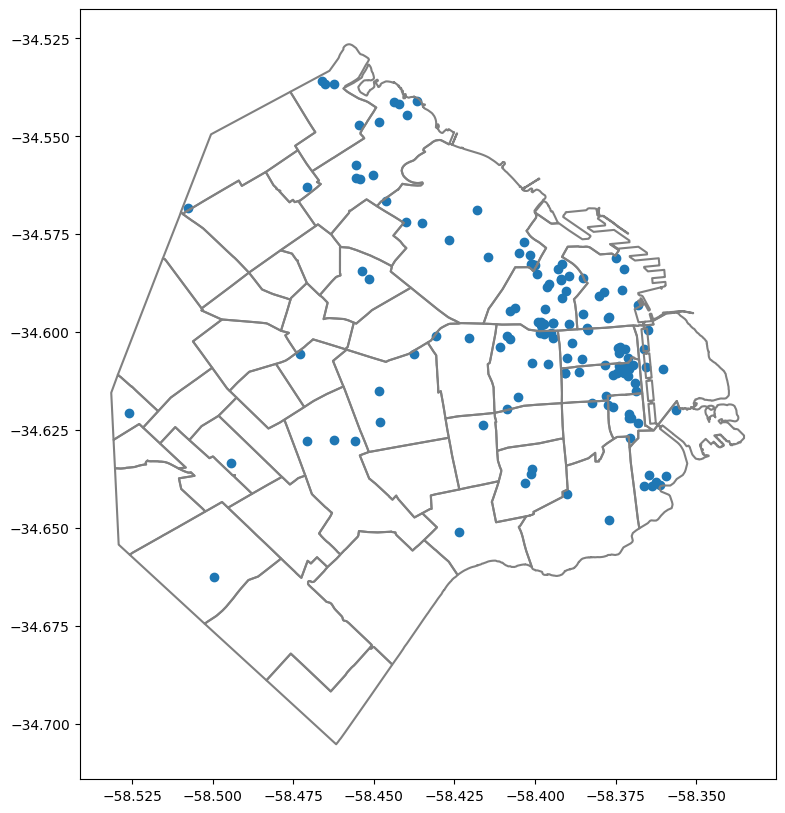

In [4]:
# Armamos el gráfico para visualizar los museos
fig, ax = plt.subplots(figsize=(10, 10))
barrios.boundary.plot(color='gray',ax=ax)
museos.plot(ax=ax)

In [5]:
len(museos)

136

## Cálculo de la matriz de distancias

Ahora construimos la matriz de distancias entre todos los museos. Como la tierra es un [geoide](https://es.wikipedia.org/wiki/Geoide) (es decir que no es [plana](https://es.wikipedia.org/wiki/Terraplanismo)), el cálculo de distancias no es una operación obvia. Una opción es proyectar a un [sistema de coordenadas local](https://geopandas.org/en/stable/docs/user_guide/projections.html), de forma tal que las distancias euclideas se correspondan con las distancias en metros. En este notebook usamos [EPSG](https://en.wikipedia.org/wiki/EPSG_Geodetic_Parameter_Dataset) 22184. 

In [6]:
# En esta línea:
# Tomamos museos, lo convertimos al sistema de coordenadas de interés, extraemos su geometría (los puntos del mapa), 
# calculamos sus distancias a los otros puntos de df, redondeamos (obteniendo distancia en metros), y lo convertimos a un array 2D de numpy
D = museos.to_crs("EPSG:22184").geometry.apply(lambda g: museos.to_crs("EPSG:22184").distance(g)).round().to_numpy()

### Matriz de adyacencia: construimos una matriz conectando a cada museo con los $m$ más cercanos

In [7]:
m = 3 # Cantidad de links por nodo
A = tf.construye_adyacencia(D,m)

## Construcción de la red en NetworkX (sólo para las visualizaciones)

In [8]:
G = nx.from_numpy_array(A) # Construimos la red a partir de la matriz de adyacencia
# Construimos un layout a partir de las coordenadas geográficas
G_layout = {i:v for i,v in enumerate(zip(museos.to_crs("EPSG:22184").get_coordinates()['x'],museos.to_crs("EPSG:22184").get_coordinates()['y']))}

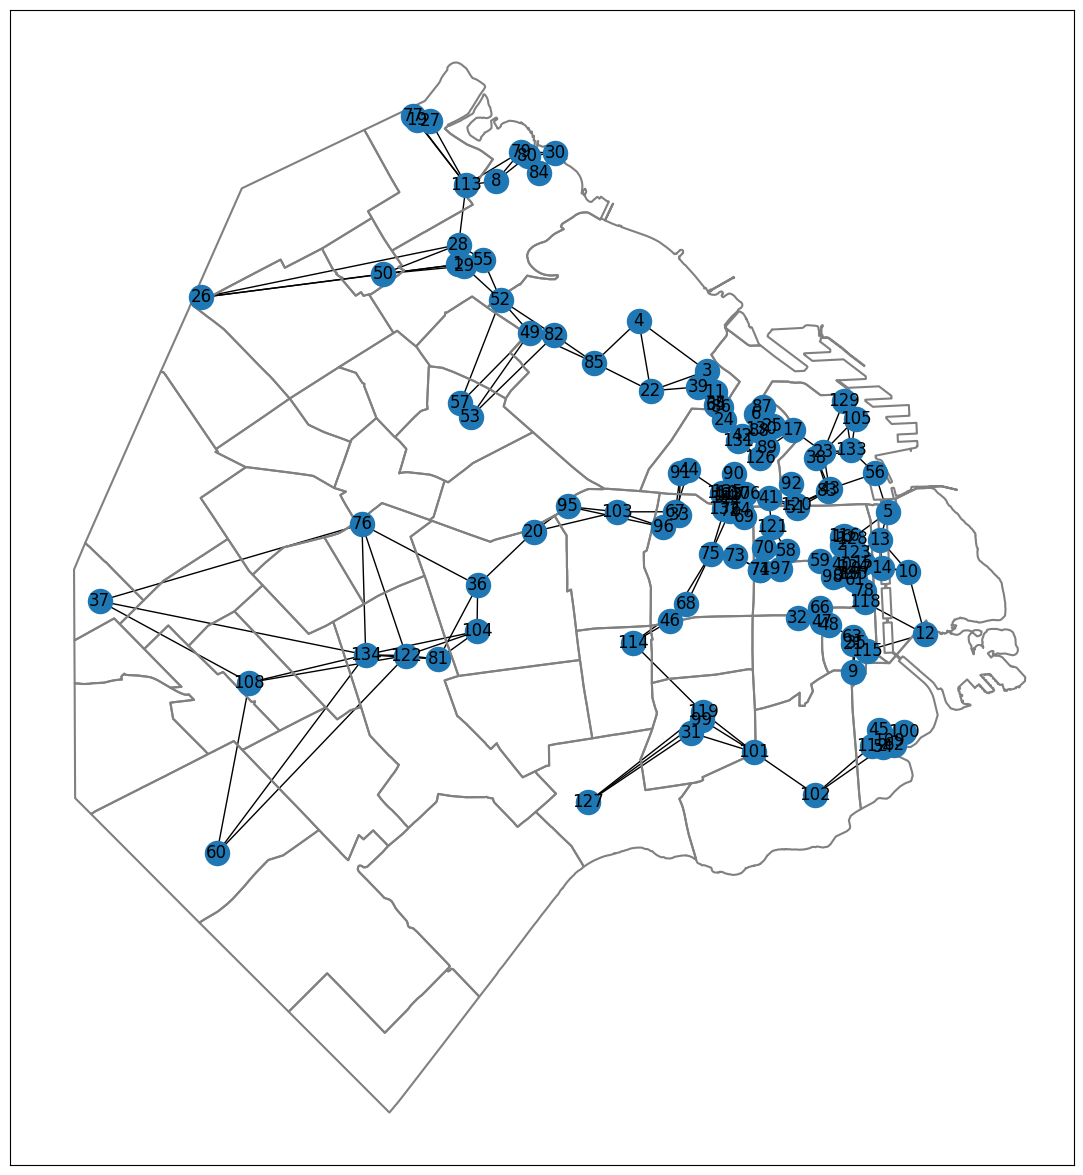

In [9]:
fig, ax = plt.subplots(figsize=(15, 15)) # Visualización de la red en el mapa
barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios
nx.draw_networkx(G,G_layout,ax=ax) # Graficamos los museos

# Resolución del TP

Aquí empieza la aventura... ¡diviertanse y consulten lo que necesiten!

## Punto 1: Entendiendo nuestro dominio del problema

Partimos de la ecuación para los puntajes de las páginas combinando los escenarios de que el puntaje de cada museo depende del puntaje de otras y de la idea del navegante aleatorio:

$$p =(1- \alpha) C * p + \frac{\alpha}{N}. \overset{\rightarrow}{1}$$

Queremos ver que:

$$M*p = \overset{\rightarrow}{1} \text{ donde } \boxed{M = \frac{N}{\alpha}(I-(1-\alpha)C)}\textcolor{green}{\blacktriangledown} $$

La idea es que juntamos los términos que tengan $p$ de un lado y despejar

$$p =(1- \alpha) C * p + \frac{\alpha}{N}. \overset{\rightarrow}{1}$$

$$p - (1- \alpha) C * p = \frac{\alpha}{N}. \overset{\rightarrow}{1}$$

Sacamos factor común:

$$p(I-(1-\alpha)C)=\frac{\alpha}{N} . \overset{\rightarrow}{1}$$

Y despejamos $p$:


$$p=\frac{\alpha}{N} . \overset{\rightarrow}{1}(I-(1-\alpha)C)^{-1}$$

Ahora si reemplazamos en la ecuación:

$$\textcolor{green}{M} \textcolor{red}{p} = \overset{\rightarrow}{1}$$

$$\textcolor{green}{\Bigl(} \frac{N}{\alpha}(I-(1-\alpha)C) \textcolor{green}{\Bigr)} . \textcolor{red}{\Bigr(}\frac{\alpha}{N}.(I-(1-\alpha)C)^{-1}\textcolor{red}{\Bigr)} = \overset{\rightarrow}{1} $$





## Punto 2:

En el punto anterior nos quedó la ecuación:

$$M \ast p =  \overset{\rightarrow}{1}$$

Donde $M$ es obtenible desde el sistema de Page Rank definida como $p =(1- \alpha) C * p + \frac{\alpha}{N}. \overset{\rightarrow}{1}$ que tiene en cuenta el recorrido aleatorio de museos.

Ahora nos interesaría saber:

¿Qué condiciones se deben cumplir para que exista una única solución a la ecuación en cuestión?

> Para que exista solución unica debe pasar que $M$ (una matriz $N \times N$) tenga sus filas L.I., si su rango es igual a la cantidad de filas significa que al hacer la triangulación de gauss no se anularan ninguna fila y el sistema tendrá solución.
> $\textcolor{red}{\text{Esto se cumple solo para sistemas homogéneos Mp = 0 ya que  bastaría con que las filas sean L.I. para garantizar }}$
> 
> $\textcolor{red}{\text{solo la trivial como única solución, pero como no es homogéneo necesitamos que sea inversible para así garantizar}}$
> 
> $\textcolor{red}{\text{el rango de la matriz completa.}}$

---

> Esto nos lleva a preguntarnos: ¿Por qué una matriz cuadrada sea inversible garantiza que tiene rango completo?
>
> La definición es: sea matriz cuadrada $A \in \mathbb{R}^{n\times n}$ es inversible si existe otra matriz $A^{−1}$ tal que:
>
> $$AA^{-1} = A^{-1}A = I_n$$
>
> Donde $I_n$ es la matriz identidad de tamaño $n\times n$
>
> El rango de una matriz $A$ es el número de filas (o columnas) linealmente independientes, lo que equivale al número máximo de columnas (o filas) que no se pueden escribir como combinación lineal de otras. En una matriz de tamaño $n\times n$, el máximo rango posible es $n$. Si el rango es $n$, decimos que tiene rango completo.
>
> Entonces tenemos que:
>
> - Si $A$ tiene inversa, entonces el sistema $Ax=b$ tiene una única solución para cualquier vector $b$.
> - Esto sólo es posible si las columnas de $A$ son linealmente independientes, porque si fueran dependientes, habría múltiples soluciones o ninguna.
> - Tener $n$ columnas linealmente independientes implica que el rango de $A$ es $n$.
>
> Nos queda que:
>
> $$ A \text{ inversible } \Longleftrightarrow rango(A) = n$$
>
> ---
>
> ### Demostración:
>
> $(\Rightarrow)$ Tenemos $A$ inversible y queremos ver que tiene rango completo.
>
> Como $A$ es inversible, existe $A^{-1}$ tal que $AA^{-1} = I_n$. Multiplicar por $A^{-1}$ es una operación que no cambia la indepedencia lineal de los vectores y como dio de resultado una base que en este caso seria la base canónica de tamaño $n$, y por definición de base, sabemos que son linealmente independientes, luego el $rango(A) = n$
>
> $(\Leftarrow)$ Tenemos que $rango(A) = n$ entonces queremos ver que es inversible.
>
> Que el $rango(A)=n$ quiere decir que las filas y columnas de $A$ son linealmente independientes (en una matriz cuadrada, el rango por filas y por columnas es igual). Entonces, el sistema $Ax=0$ sólo tiene la solución trivial $x=\overset{\rightarrow}{0}$. Por el teorema de la unicidad de soluciones, eso significa que $A$ define una transformación lineal inyectiva (monomorfismo). Y en un espacio de dimensión finita, toda transformación lineal inyectiva entre espacios de igual dimensión es también sobreyectiva (epimorfismo por el teorema de la dimensión que me dice que $dim(A) = dim(Nu(A))+ dim(Im(A)) \Rightarrow n = 0 + dim(Im(A)) \Rightarrow dim(Im(A)) = n$), y por lo tanto, biyectiva (isomorfismo). Eso implica que existe una transformación inversa, es decir, $A$ es invertible.
>
> Luego queda demostrado que:
>
> $$A \text{ inversible } \Longleftrightarrow rango(A) = n$$
>
> $\square$
> ---
>
> En nuestro caso particular, necesitaremos que $M$ sea inversible

¿Se cumplen estas condiciones para la matriz $M$ tal como fue construida para los museos, cuando $0 < \alpha < 1$?

> Queremos demostrar que
>
> $$M = \frac{N}{\alpha}(I-(1-\alpha)C)$$
>
> es inversible, bajo las condiciones de que:
>
> - $C \in \mathbb{R}^{N\times N}$ es una matriz estocástica por columnas, es decir, sus columnas suman 1.
> - $0 < \alpha < 1$
>
> ---
> 
> Para ver esto, vamos a usar las propiedades de los autovalores que dice que una matriz cuadrada $A$ es invertible si y solo si todos sus autovalores son distintos de cero. O dicho de otra forma:
>
> - Si algún autovalor $\lambda = 0$, entonces la matriz no es inversible.
> - Si ningún autovalor es cero, entonces la matriz es inversible.
>
> Porque si $\lambda = 0$ es autovalor, entonces existe un vector no nulo $\overset{\rightarrow}{v}$ tal que $A\overset{\rightarrow}{v} = 0$, lo cual implica que $A$ tiene un núcleo distinto de cero $\Rightarrow$ no es inversible.
>
> ---
>
> Volviendo a nuestro contexto, para ver que $M$ se inversible tenemos que ver que no tenga autovalores iguales a $0$, en otras palabras queremos que $I-(1-\alpha)C$ sea inversible, y lo es, pues:
>
> - Sus autovalores son de la forma $1−(1−α)\lambda$, donde $\lambda$ son los autovalores de $C$
> - El único $\lambda$ que resultaría en un autovalor $0$ para $M$, sería: $\frac{1}{1 - \alpha}$,
> - Como $C$ es una matriz estocástica, cumple con tener autovalores a lo sumo $1$,
> - $1 - \alpha < 1 \Leftrightarrow 1 < \frac{1}{1 - \alpha} = \lambda$, que no puede ser autovalor de $C$ pues es estocástica.
> - Por lo tanto, los autovalores de $M$ son de la forma $1−(1−α)\lambda \neq 0$
>
> $\Rightarrow M$ es inversible ya que siempre tiene autovalores distintos de 0 para $0<\alpha<1$
>
---
>
> ## Ahora sin usar $\textcolor{red}{\text{ autovalores/autovectores}}$
>
> ---
>
> Tenemos $M$ definida como:
>
> $$M = \frac{N}{\alpha}(I-(1-\alpha)C)$$
>
> Los datos que tenemos son:
>
> - $C \in \mathbb{R}^{n \times n}$ es estocástica por columnas $\rightarrow \|C\|_1 = 1$
> - $0 < \alpha < 1 \rightarrow$ si tomamos $B = (1-\alpha)C$ aplicando $\|.\|_1$ obtenemos que:
>
>    $$\|B\|_1 = (1-\alpha)\|C\|_1 = 1-\alpha < 1$$
>
> Entonces queremos ver que $M=\frac{N}{\alpha}(I-B)$ es invertible, es decir que $ker(M) = \{0\}$.
>
> ## Demostramos por absurdo
>
> 1. Supongamos que $M$ no es invertible, entonces existe un vector $w \in \mathbb{R}^n, w\neq 0$ tal que:
>
>    $$Mw = 0 \Rightarrow (I-B)w = 0 \Rightarrow Bw=Iw = w $$
>
> 2. Tomamos norma 1 ambos lados:
>
>    $$\|Bw\|_1 = \|w\|_1 $$
>
>    Pero también sabemos que
>
>    $$\|Bw\|_1 \leq \|B\|_1 . \|w\|_1 < \|w\|_1$$
>
>    (porque $\|B\|_1 = 1-\alpha < 1$ y $w \neq 0 \Rightarrow \|w\|_1 > 0$, o sea, multiplico la norma de $w$ por un número entre cero y uno lo hace más chico)
>
>    Por lo tanto:
>
>    $$\|Bw\|_1 < \|w\|_1 $$
>
>    Pero eso contradice el hecho de que $$Bw= w \Rightarrow  \|Bw\|_1 = \|w\|_1 $$
>
> 3. Contradicción! Entonces no puede existir tal $w \neq 0$ que cumpla $Bw=w$. Por lo tanto:
>
>    $$ker(I-B)=\{0\} \Rightarrow I-B \text{ es invertible } \Rightarrow M \text{ es invertible }$$
>
>    Pues Multiplicar por un número, en este caso $\frac{N}{\alpha}$ no afecta la invertibilidad

## Punto 3:

In [ ]:
a = 1/5
n = len(museos)
b = np.ones((n))
m = 3
A = tf.construye_adyacencia(D, m)

In [ ]:
p = tf.calcula_pagerank(A, n, a, b)
p

array([0.00328536, 0.00792782, 0.00725028, 0.01227064, 0.0049242 ,
       0.00622143, 0.01313636, 0.00921321, 0.00420168, 0.00147059,
       0.00346944, 0.0129492 , 0.00147059, 0.00534694, 0.00499714,
       0.00705332, 0.00725028, 0.00414187, 0.01051577, 0.00735294,
       0.00636296, 0.00421601, 0.00886356, 0.01335641, 0.00778263,
       0.01370822, 0.00147059, 0.00735294, 0.01052414, 0.01152911,
       0.00826207, 0.00431839, 0.00580495, 0.00812683, 0.01206465,
       0.00421601, 0.00885206, 0.00302768, 0.00653336, 0.00828818,
       0.00328536, 0.01047212, 0.0053697 , 0.01195744, 0.00383548,
       0.00711862, 0.00735294, 0.00812693, 0.00812693, 0.02143789,
       0.00147059, 0.00833931, 0.01566562, 0.00735294, 0.00822366,
       0.01016442, 0.00653016, 0.00735294, 0.00630853, 0.00147059,
       0.00147059, 0.00665163, 0.00718516, 0.006022  , 0.00809863,
       0.01858679, 0.00812693, 0.01351394, 0.00735294, 0.00471004,
       0.01126957, 0.01194101, 0.01430006, 0.00436191, 0.01194

### 3b.

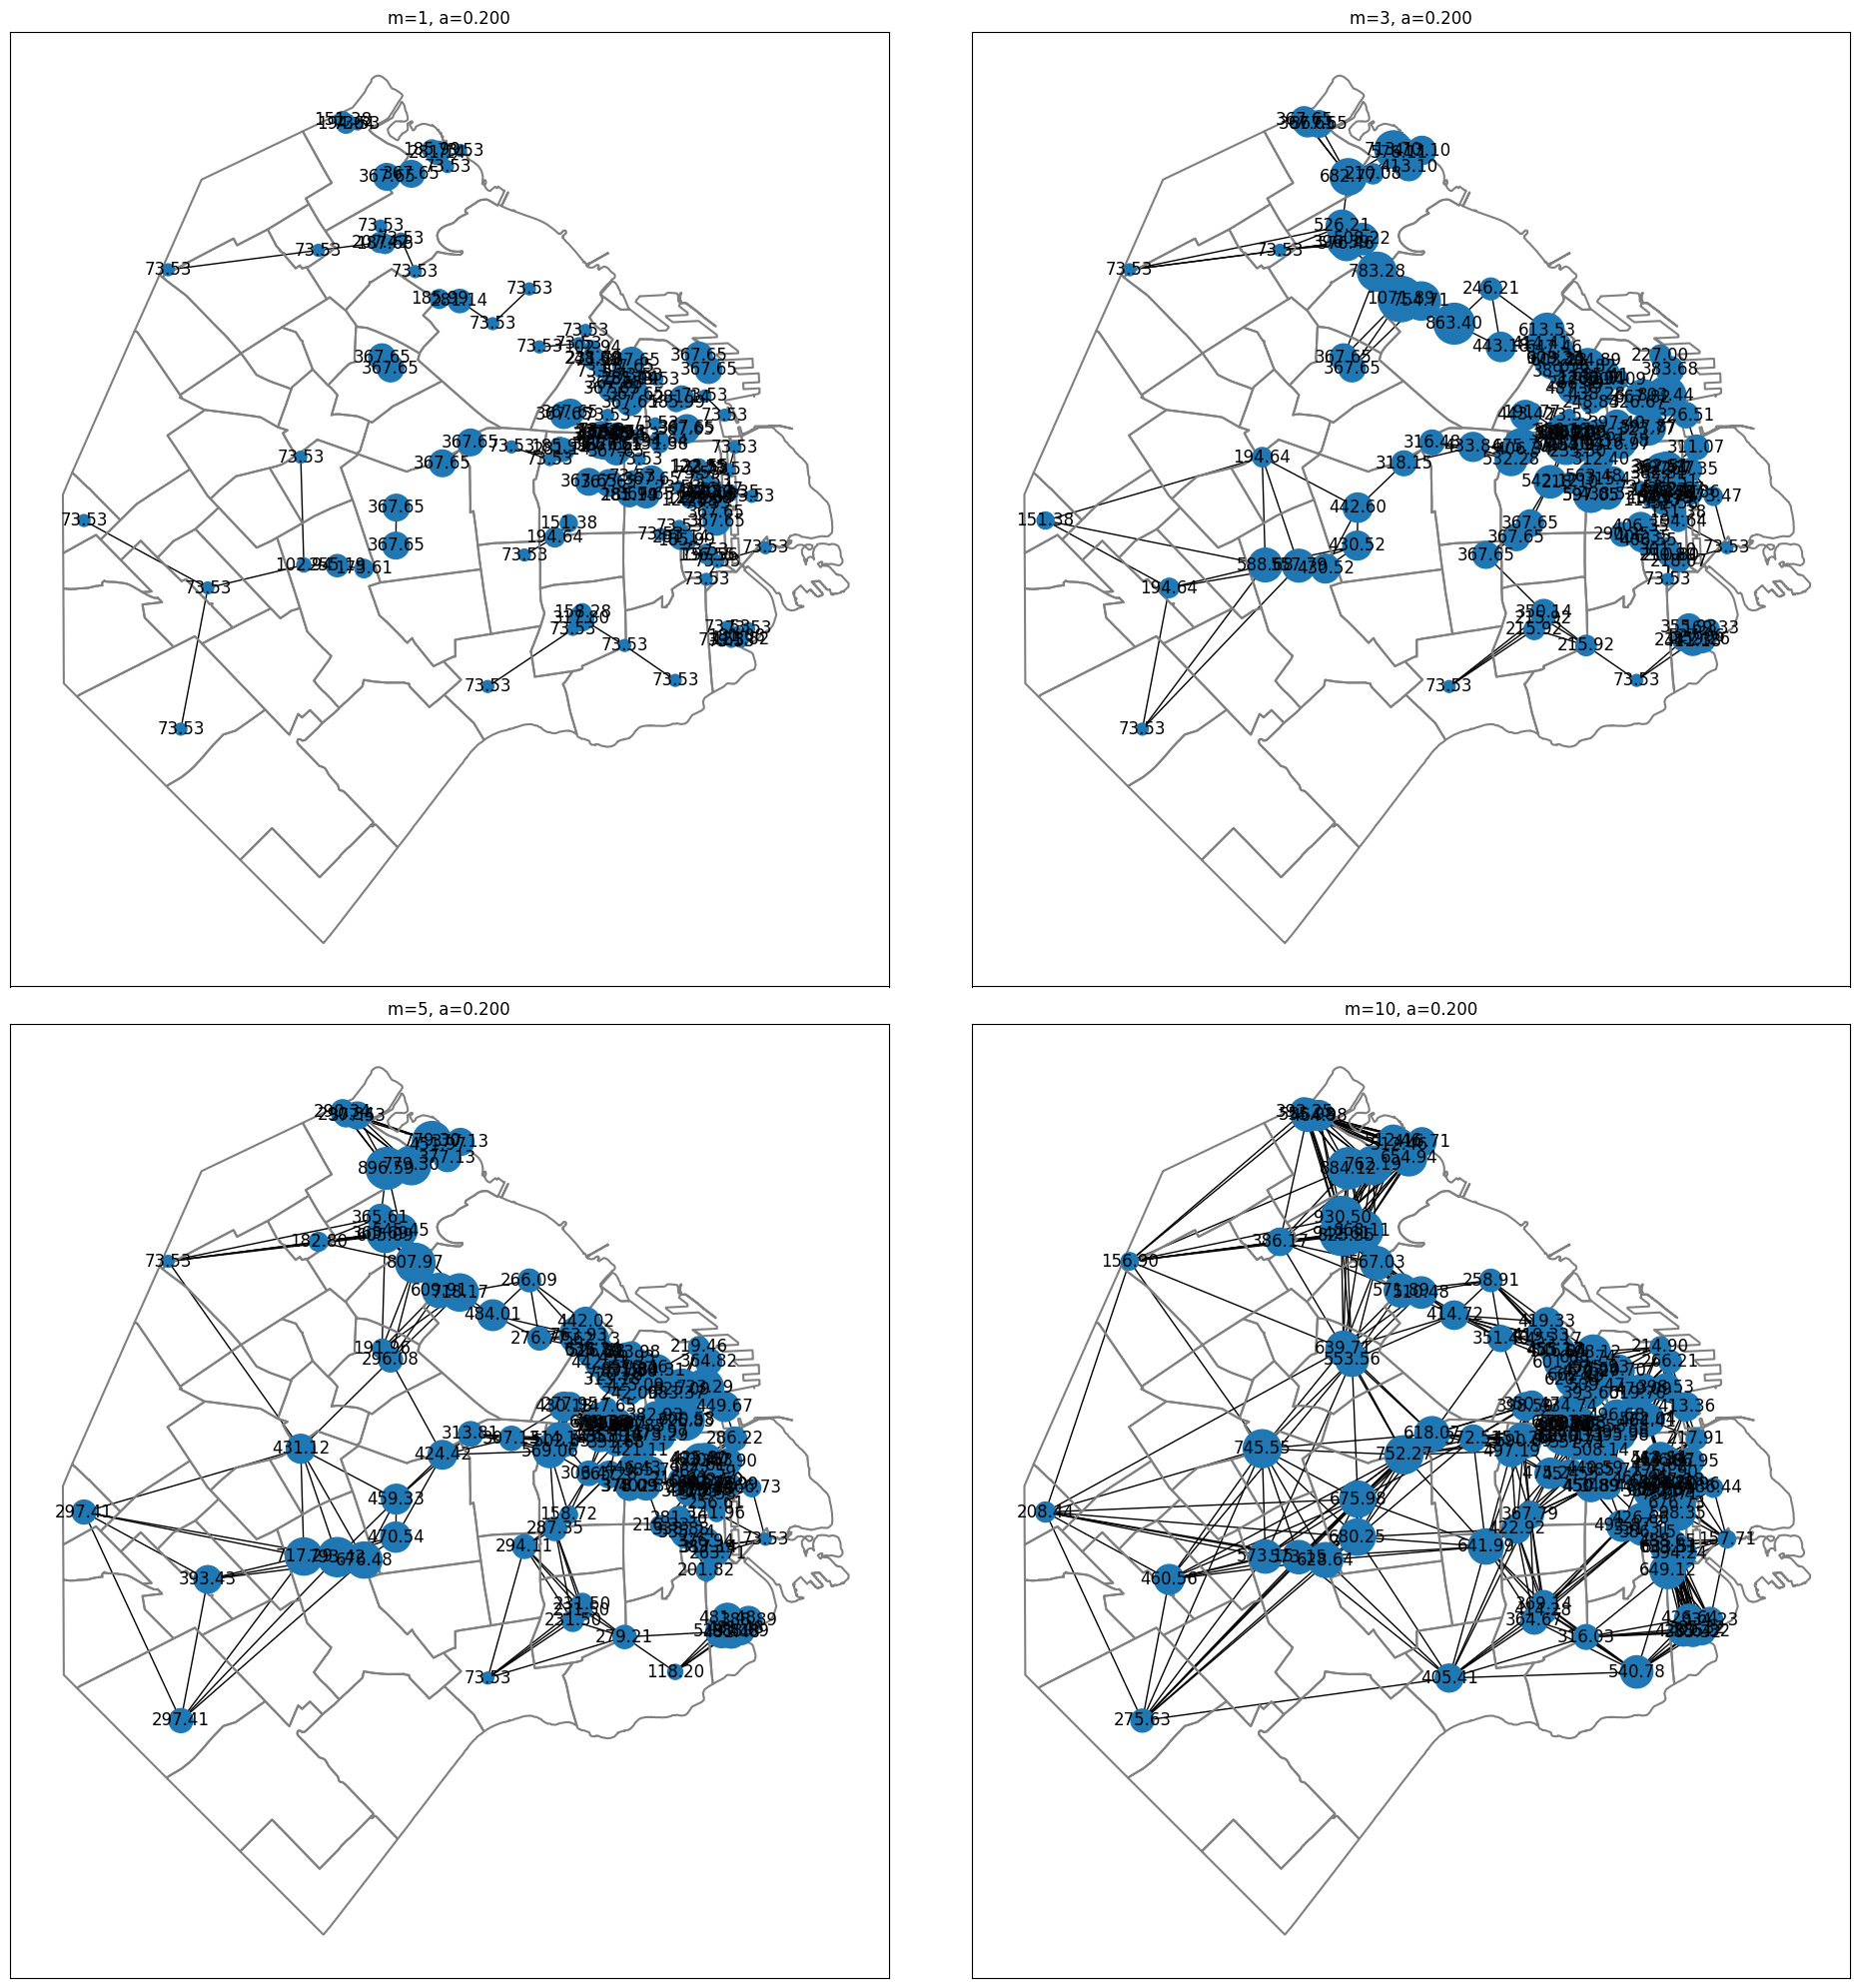

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
a = 1/5  # Fixed value for a
m_values = [1, 3, 5, 10]

top_3_indices = set() # Guardamos los indices de los top 3

# Creamos un grafico por espacio en el grid
for ax, m in zip(axes.flat, m_values):
  A = tf.construye_adyacencia(D, m)

  p = tf.calcula_pagerank(A, n, a, b) * 50000

  top_3_indices.update(list(np.argsort(p)[-3:]))

  G = nx.from_numpy_array(A) # Construimos la red a partir de la matriz de adyacencia

  # Construimos un layout a partir de las coordenadas geográficas
  G_layout = {i:v for i,v in enumerate(zip(museos.to_crs("EPSG:22184").get_coordinates()['x'],museos.to_crs("EPSG:22184").get_coordinates()['y']))}

  barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios
  nx.draw_networkx(G,G_layout,ax=ax, node_size=p, labels={i: f"{p[i]:.2f}" for i in range(D.shape[0])}) # Graficamos los museos
  ax.set_title(f'm={m}, a={a:.3f}')

plt.tight_layout()
plt.show()

### 3c.

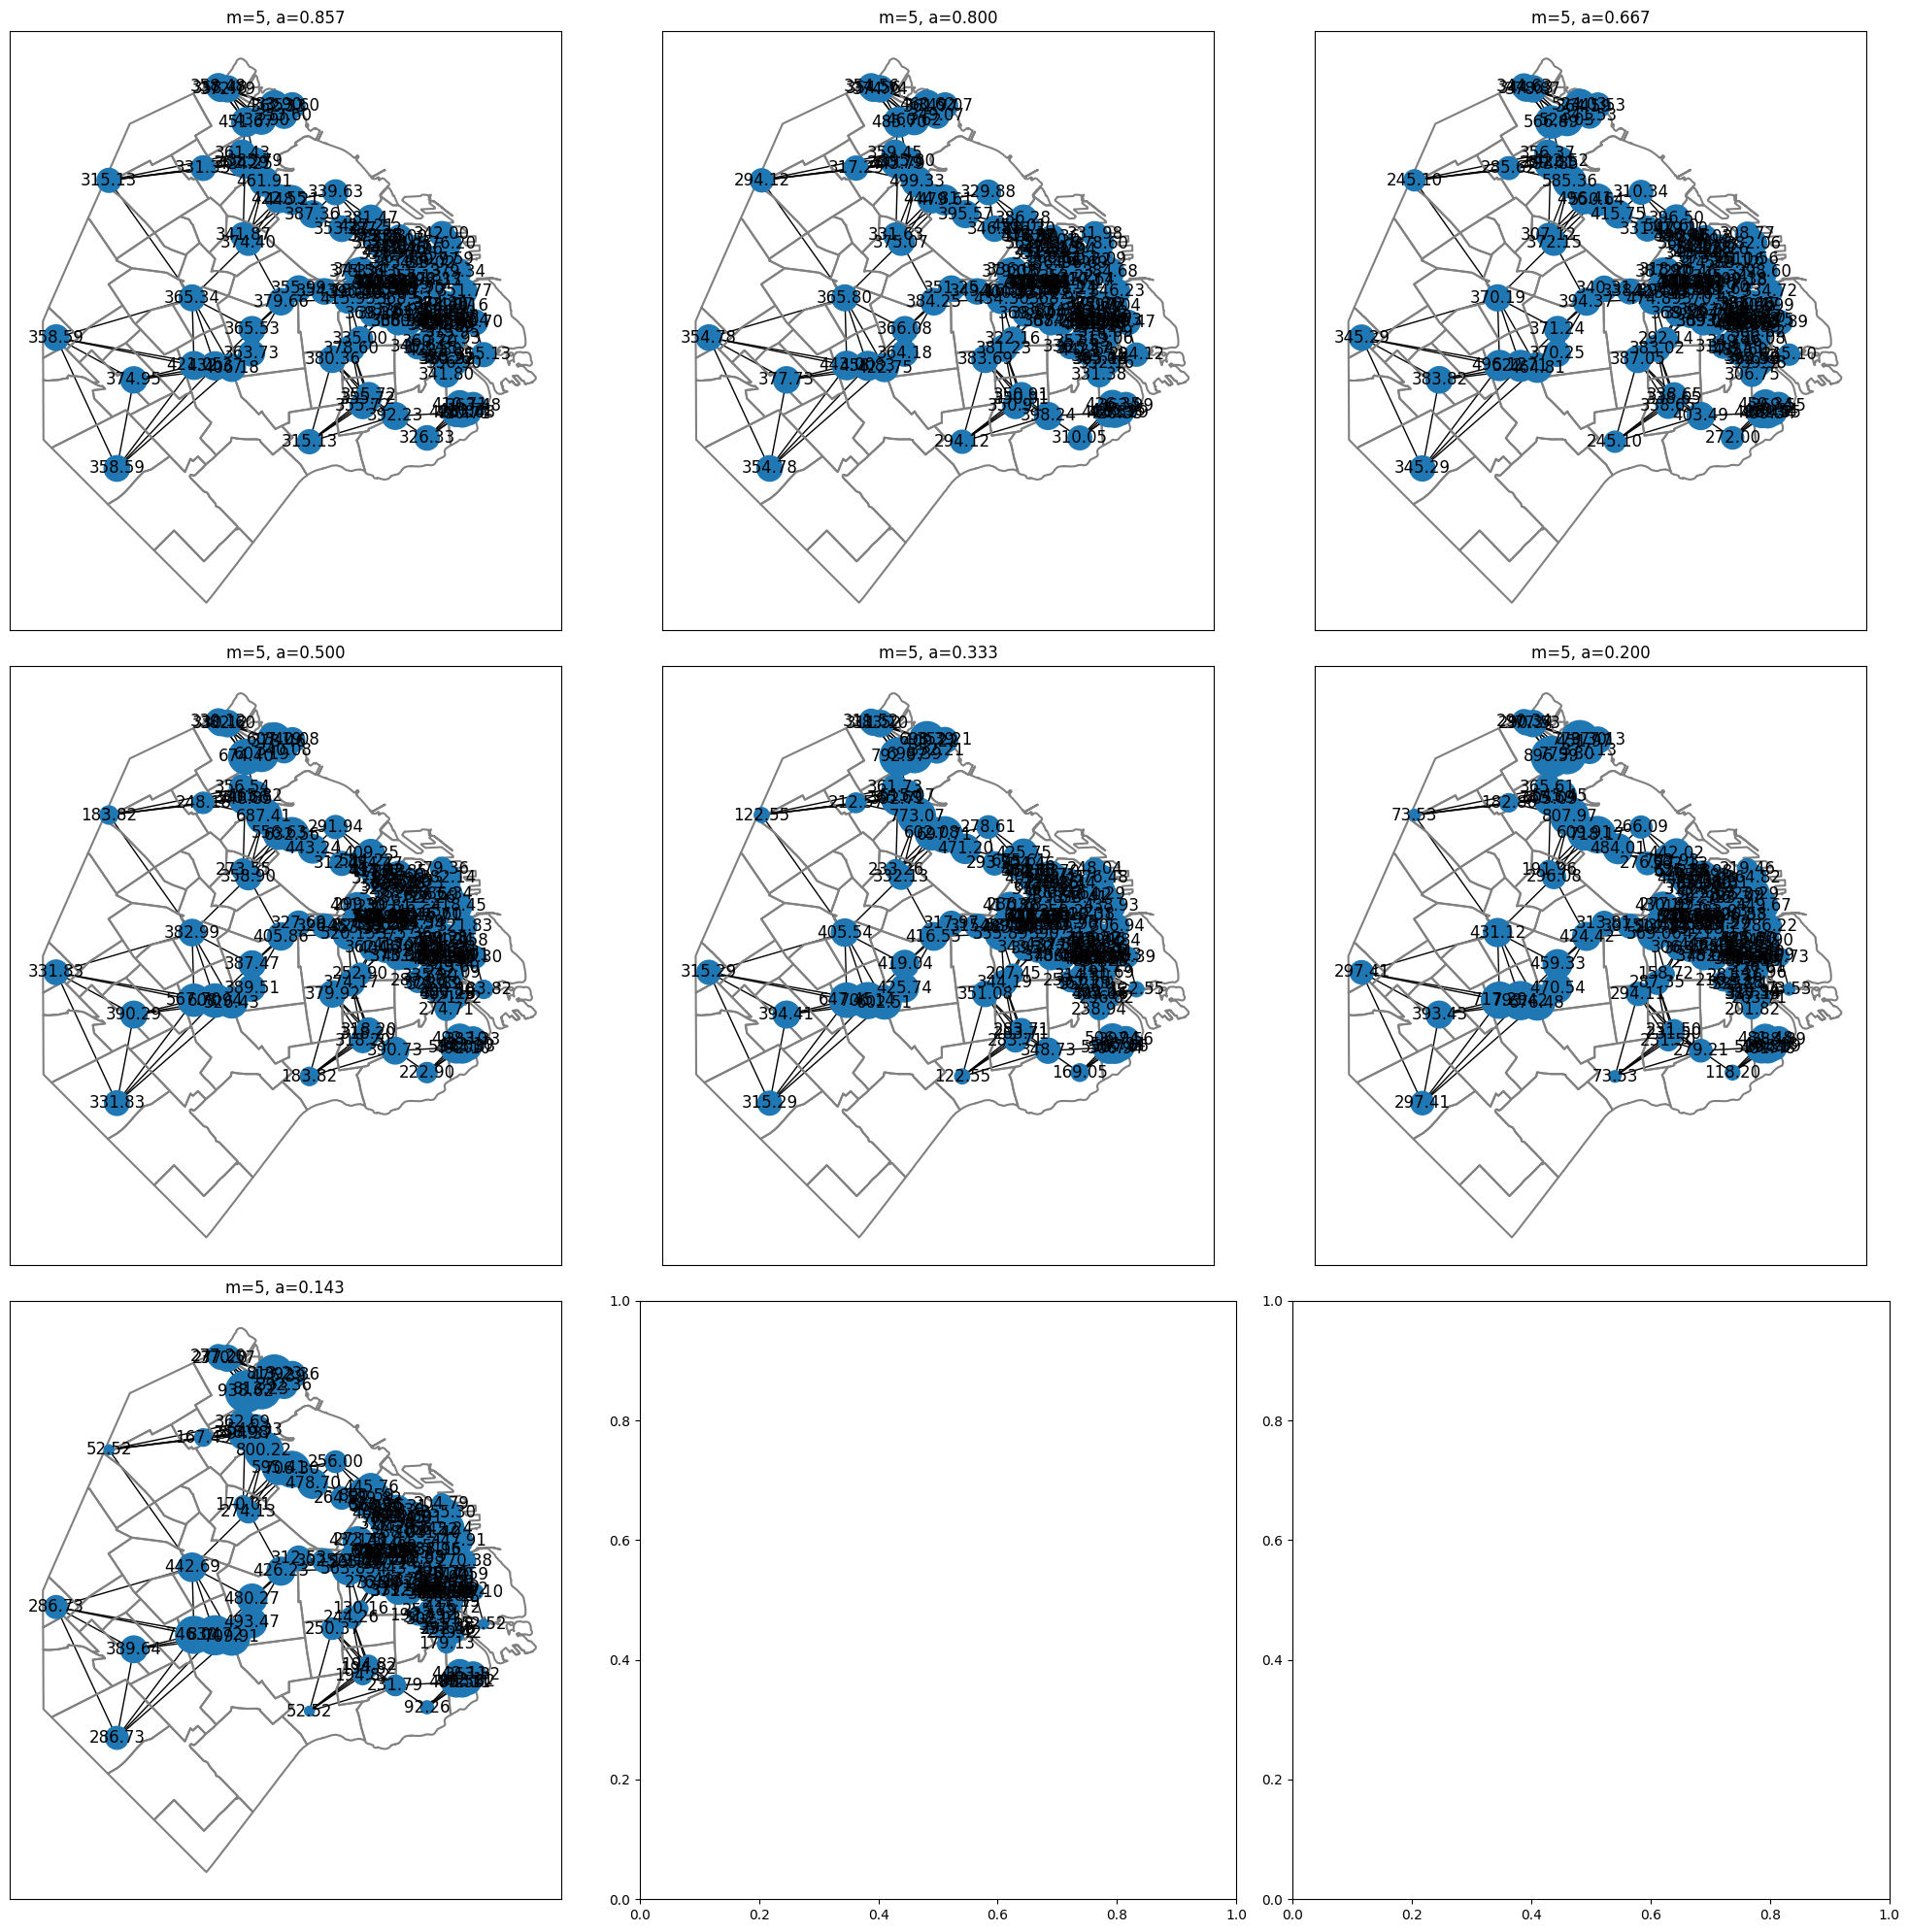

In [ ]:
m = 5

a_values = [6/7, 4/5, 2/3, 1/2, 1/3, 1/5, 1/7]

A = tf.construye_adyacencia(D, m)

G = nx.from_numpy_array(A) # Construimos la red a partir de la matriz de adyacencia

# Construimos un layout a partir de las coordenadas geográficas
G_layout = {i:v for i,v in enumerate(zip(museos.to_crs("EPSG:22184").get_coordinates()['x'],museos.to_crs("EPSG:22184").get_coordinates()['y']))}



fig, axes = plt.subplots(3, 3, figsize=(20, 20))

for ax, a in zip(axes.flat, a_values):
  p = tf.calcula_pagerank(A, n, a, b) * 50000
  top_3_indices.update(list(np.argsort(p)[-3:]))
  barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios

  nx.draw_networkx(G,G_layout,ax=ax, node_size=p, labels={i: f"{p[i]:.2f}" for i in range(D.shape[0])}) # Graficamos los museos
  ax.set_title(f'm={m}, a={a:.3f}')


plt.tight_layout()
plt.show()

### 3a.a.

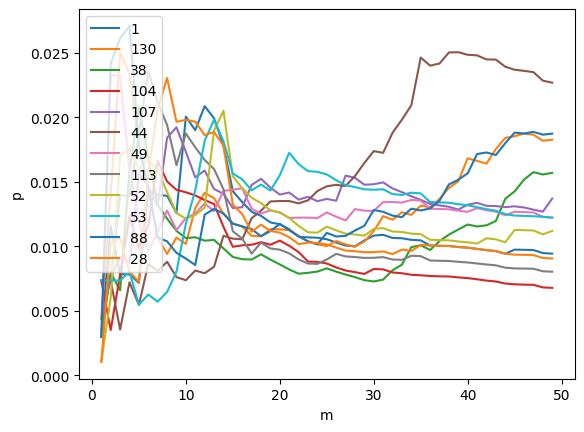

In [31]:
# Grafico p en función de m
m_space = range(1, 50)

museos_valores = { museo: [] for museo in top_3_indices }

for m in m_space:
  A = tf.construye_adyacencia(D, m)
  p = tf.calcula_pagerank(A, n, a, b)
  # Agarro los p que me interesan
  for museo in top_3_indices:
    museos_valores[museo].append(p[museo])

for museo in museos_valores:
  plt.plot(m_space, museos_valores[museo], '-',label=f'{museo}')

plt.xlabel('m')
plt.ylabel('p')
plt.legend()
plt.show()

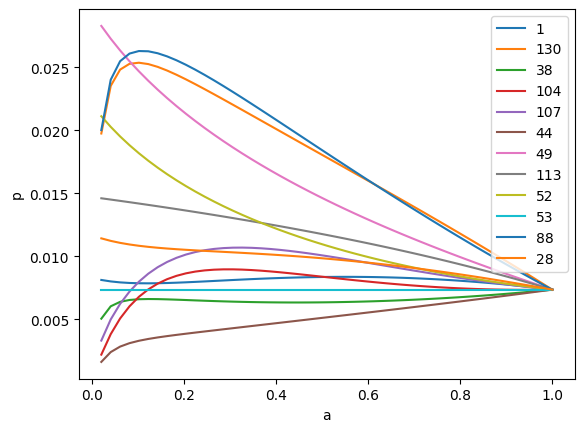

In [37]:
# Grafico p en función de m
a_space = np.linspace(0, 1, 50)
m=3

museos_valores = { museo: [] for museo in top_3_indices }
A = tf.construye_adyacencia(D, m)

for a in a_space:
  p = tf.calcula_pagerank(A, n, a, b)
  # Agarro los p que me interesan
  for museo in top_3_indices:
    museos_valores[museo].append(p[museo])

for museo in museos_valores:
  plt.plot(a_space, museos_valores[museo], '-',label=f'{museo}')

plt.xlabel('a')
plt.ylabel('p')
plt.legend()
plt.show()

##### Conclusiones

- **¿Son estables las posiciones en el ranking?**
Cuando variamos la cantidad de conexiones (m), las posiciones en el ranking cambian de manera abrupta.
En cambio cuando variamos a, mientras van convergiendo a 1 todos los valores p de los museos, las posiciones se mantienen relativamente estables. Esta convergencia entre los museos se puede explicar por la aleatoriedad del sistema cuando a = 1, ya que deja de importar que tan cerca estén los museos entre sí para los visitantes.

- **¿Hay museos que solo son relevantes en redes con pocas conexiones?**
Cuando el a es cercano a 1, la aleatoriedad es tal que incluso si es un museo muy alejado del resto, hay bastantes visitantes eligiendolo.

- **Hay museos que se vuelven mas relevantes mientras mas conexiones aparecen?**
Los museos que estan en zonas "céntricas" (osea que están cerca de muchos otros) adquieren mayor relevancia ya que tiene muchas conexiones "fuertes" (la probabilidad de ser visitado es inversamente proporcional a la distancia).

## Punto 4:

Suponemos que cada persona realiza $r$ visitas antes de abandonar la red de museos. Si el número total de visitas que recibió cada museo está dado por el vector $\overset{\rightarrow}{w}$ tal que $\overset{\rightarrow}{w}_i$ tiene el número total de visitantes que se recibieron en el museo $i$, queremos mostrar que el vector $\overset{\rightarrow}{v}$, que tiene en su componente $\overset{\rightarrow}{v}_i$ el número de personas que tuvo al museo $i$ como punto de entrada a la red, que puede estimarse como:

$$\overset{\rightarrow}{v} = B^{-1} \overset{\rightarrow}{w}$$

Con $B = \sum_{k=0}^{r-1} C^k$

Tip: recordar que si $\overset{\rightarrow}{v}$ da el número de visitantes que entraron a la red en cada museo, entonces luego de $k$ pasos podemos esperar la distribución $C^k\overset{\rightarrow}{v}$ sobre el total de museos.

> Dado que $\overset{\rightarrow}{w}$ es el vector que en cada componente $\overset{\rightarrow}{w}_i$ guarda el total de visitantes recibidos por el museo $i$, y dado $\overset{\rightarrow}{v}$ que guarda en cada posición $\overset{\rightarrow}{v}_i$ el número de personas con el museo $i$ como primer museo a visitar.
>
> Llamamos $v_0 = \overset{\rightarrow}{v}$
>
> Tenemos $C$ la matriz de transiciones que nos permite realizar los "pasos" de los visitantes tal que:
>
> $$v_{k+1} = C v_k $$
>
> Como suponemos que $r$ visitas o "pasos", podemos decir que $\overset{\rightarrow}{w}$ es la suma de cada "paso":
>
> $$\overset{\rightarrow}{w} = \sum_{k=0}^{r-1} v_k$$
>
> Nos serviría saber que: $v_k = C^k v_0$ para continuar.
>
> <u>Usamos inducción</u>
>
> - Porposición: $p(k): v_k = C^kv_0 \forall k \in \mathbb{N}$
> - Caso base: $p(1): v_1 = C * v_0$ Se cumple pues anteriormente se describió que $v_0$ guarda los primeros visitantes y con $C$ transiciona a $v_1$
> - Paso inductivo: sea $n \in \mathbb{N}$
>    - Defino la HI: $p(n): V_n = C^nv_0$
>    - Entonces suponiendo que vale $p(n)$ quiero ver que vale $p(n+1) : v_{n+1} = C^{n+1}v_0$
>
> - Desarrollamos
> 
>    Por def de $C$ matriz de transiciones:
>
>    $$v_{n+1}=Cv_n $$
>
>    $$\overset{HI}{\Rightarrow} v_{n+1}=CC^nv_0 =C^{n+1}v_0$$
>
>    Lo que queríamos ver para $p(n+1)$
>
> $\Rightarrow$ probamos que vale $v_k = C^k v_0 \forall k\in \mathbb{N}$
>
> ---
>
> Reemplazando $v_k$: 
>
> $$\overset{\rightarrow}{w} = \sum_{k=0}^{r-1} v_k = \sum_{k=0}^{r-1} C^k v_0 \Rightarrow \overset{\rightarrow}{w} = v_0 \sum_{k=0}^{r-1} C^k$$
>
> Llamamos $B = \sum_{k=0}^{r-1} C^k$, que podemos suponer inversible
>
> $$\overset{\rightarrow}{w} = v_0B \Leftrightarrow B^{-1}\overset{\rightarrow}{w} = v_0 \Leftrightarrow \boxed{ \overset{\rightarrow}{v} =  B^{-1}\overset{\rightarrow}{w}}$$
>
> $\square$
> ---



## Punto 5:

Se nos provee de un vector $\overset{\rightarrow}{w}$ concreto dado en el archivo *visitas.txt* que leeremos con la función np.load_txt con unpack = False para mantener a $\overset{\rightarrow}{w}$ como "vector columna".

Ahora usamos $v = B^{-1}w$, probado en el ejercicio anterior y suponiendo que la cantidad de pasos de los visitantes fue $r = 3$, lo cual tendrá impacto en B pues: $B = \sum_{k=0}^{r-1} C^k$, como r es 3, $B = \sum_{k=0}^{2} C^k$

Con C nuestra matriz de transiciones general que usa la inversa de las distancias entre museos.

Como $\overset{\rightarrow}{v}$ es un vector columna que guarda en cada una de sus posiciones $\overset{\rightarrow}{v}_{i}$ la cantidad de personas con el museo i como primer destino,

Al calcular $\lVert \overset{\rightarrow}{v} \rVert_{1}$ obtendremos la suma de todos los visitantes iniciales en nuestra red.

In [ ]:
# Cargamos nuestro vector w
vector_w = np.loadtxt("https://drive.usercontent.google.com/download?id=178G2cGmJih21aMoMdU_R1tq9OtCzR37U&export=download&authuser=0&confirm=t&uuid=99e36ab6-3606-462d-b97f-79b243785728&at=APcmpow_V3-hFPd_rLJf6LpZbYQB:1745535036588", unpack = False) # vector columna

r = 3 # Cantidad de pasos

C = tf.inversa_por_LU(D)
# Como ya tenemos C,
B = tf.calcula_B(C,3)

# Ya podemos conocer al vector v
vector_v = tf.inversa_por_LU(B) @ vector_w

# Ya podemos conocer la cantidad total de visitantes iniciales
vector_v_matrix = np.reshape(vector_v, (-1, 1))
vector_w_matrix = np.reshape(vector_w, (-1, 1))

print(f"La cantidad total de visitantes al inicio fue {tf.norma_1_matriz(vector_v_matrix)}")
print(f"La cantidad total de visitantes en los {r} pasos fue {tf.norma_1_matriz(vector_w_matrix)}")

M.shape (136, 1)
La cantidad total de visitantes al inicio fue 136604.99999999994
M.shape (136, 1)
La cantidad total de visitantes en los 3 pasos fue 409815.0


## Punto 6:

Si suponemos que nos enteramos de que el número total de visitantes tiene un error del $5\%$, y necesitamos estimar cómo se propaga ese error a la estimación del número total de visitantes. Llamemos $\overset{\sim}{w}$ y $\overset{\sim}{v}$ son los valores reales para el total de visitas y el total de primeras visitas respectivamente. Si expresamos este problema usando el número de
condición tenemos que

$$\frac{\| v - \overset{\sim}{v} \|_1}{\|v\|_1} \leq cond_1(B) \frac{\| w - \overset{\sim}{w} \|_1}{\|w\|_1}$$

Calculamos el número de condición de $B$ y estimamos la cota para el error de estimación de $v$

> Sabemos que
>
> $$v = B^{-1}w$$
>
> Y nos enteramos que $w$ tiene el error de 5%, o sea:
>
> $$ \frac{\| w - \overset{\sim}{w} \|_1}{\|w\|_1} = 0.05$$
>
> Queremos estimar el error relativo en $v$ usando el número de condición en norma 1 de la matriz $B$, con esta desigualdad:
>
> $$\frac{\| v - \overset{\sim}{v} \|_1}{\|v\|_1} \leq cond_1(B) \frac{\| w - \overset{\sim}{w} \|_1}{\|w\|_1}$$
>
> Por lo tanto:
>
> $$\frac{\| v - \overset{\sim}{v} \|_1}{\|v\|_1} \leq cond_1(B) * 0.05$$
>
> Sabemos que el número condición en norma 1 se define como:
>
> $$cond_1(B)=\|B\|_1 * \|B^{-1}\|_1 $$
>
> Donde
> - $\|B\|_1$ es la máxima suma de valores absolutos por columna.
> - $\|B^{-1}\|_1$ lo mismo pero para $B$ inversa.


In [ ]:
cond_B = tf.calcular_condicion_1(B)
error_w = 0.05
cota_error_v = cond_B * error_w

print("Numero de cond: ", cond_B)
print("Cota de error: ", cota_error_v)

M.shape (136, 136)
M.shape (136, 136)
Numero de cond:  5.051771176665007
Cota de error:  0.2525885588332503


# Extras

Para graficar la red con un conjunto de puntajes (como el Page Rank)

{0: Text(4924405.086723215, 6160838.106023658, '0'),
 1: Text(4917216.80489522, 6166701.553530234, ''),
 2: Text(4924486.298584606, 6161409.256658559, ''),
 3: Text(4921922.052887296, 6164690.544542129, ''),
 4: Text(4920636.67547965, 6165640.199444978, ''),
 5: Text(4925338.320928778, 6162016.528710163, ''),
 6: Text(4922856.100832731, 6163868.567721188, ''),
 7: Text(4922641.894255253, 6162355.100129171, ''),
 8: Text(4917938.7521918025, 6168273.372961773, ''),
 9: Text(4924683.52693892, 6158996.617208998, ''),
 10: Text(4925725.9600755945, 6160896.846339954, ''),
 11: Text(4922075.10183836, 6164294.738410278, ''),
 12: Text(4926038.146946977, 6159721.190876993, ''),
 13: Text(4925200.592014585, 6161503.005610317, ''),
 14: Text(4925229.168803978, 6160973.145341254, ''),
 15: Text(4924875.410406244, 6161061.981187101, ''),
 16: Text(4924474.294424794, 6161547.549492302, ''),
 17: Text(4923553.755484842, 6163571.336254905, ''),
 18: Text(4924615.955668659, 6160843.2491330765, ''),
 19

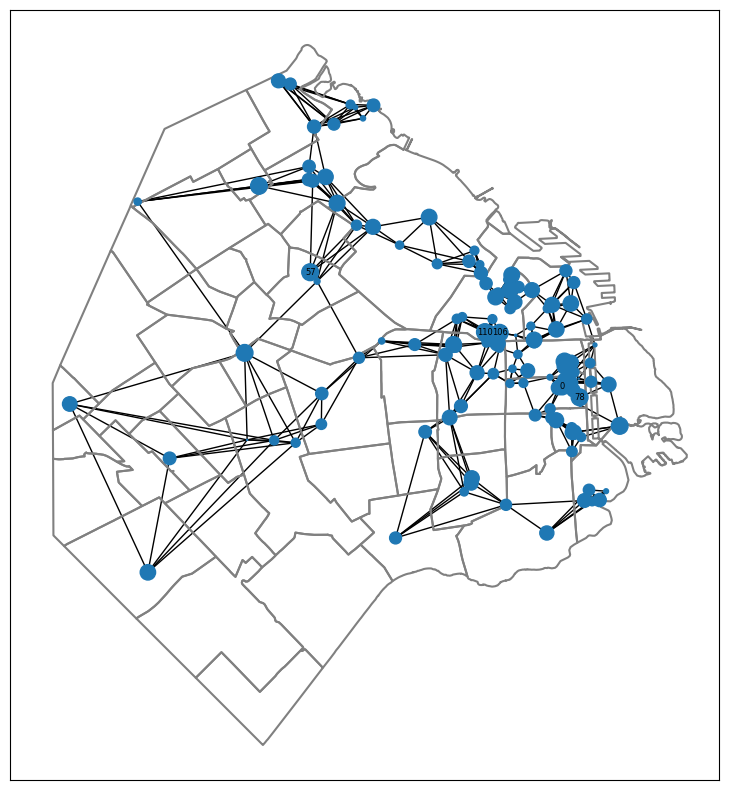

In [16]:
factor_escala = 1e4 # Escalamos los nodos 10 mil veces para que sean bien visibles
fig, ax = plt.subplots(figsize=(10, 10)) # Visualización de la red en el mapa
barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios
pr = np.random.uniform(0,1,museos.shape[0])# Este va a ser su score Page Rank. Ahora lo reemplazamos con un vector al azar
pr = pr/pr.sum() # Normalizamos para que sume 1
Nprincipales = 5 # Cantidad de principales
principales = np.argsort(pr)[-Nprincipales:] # Identificamos a los N principales
labels = {n: str(n) if i in principales else "" for i, n in enumerate(G.nodes)} # Nombres para esos nodos
nx.draw_networkx(G,G_layout,node_size = pr*factor_escala, ax=ax,with_labels=False) # Graficamos red
nx.draw_networkx_labels(G, G_layout, labels=labels, font_size=6, font_color="k") # Agregamos los nombres

# Detección de comunidades con métodos espectrales

## Punto 1: autovectores y autovalores de $L$ y $R$

1. Mostrar que el vector de unos 1 es autovector de las matrices R y L.

   > Veamos que tanto $L$ como $R$ tienen autovector $\overset{\rightarrow}{1}$ asociado a $0$.
   >
   > - Con $L$:
   >
   >   $$L = K - A$$
   >
   >   Es una matriz que en la diagonal tiene el grado del nodo $i-$esimo y luego $-1$ paras las conexiones, ya que estoy restando la matriz de adyacencia donde tiene ceros en la diagonal.
   >
   >   $$L \begin{pmatrix}1\\ 1\\ \vdots \end{pmatrix} = \text{ da como resultado una matriz que suma las filas}$$
   > 
   >   Como en cada fila tenemos $-\sum_{j=1}^n A_{ij}, \forall 1 \leq i \leq n$ y $k_i = \sum_{j=1}^n A_{ij}$ entonces tenemos que las filas suman $0$ (como es simétrica vale para las columnas).
   >
   >   Nos queda que:
   >
   >   $$L. \overset{\rightarrow}{1} = \overset{\rightarrow}{0} = 0 . \overset{\rightarrow}{1} \Rightarrow L \text{ tiene autovector } \overset{\rightarrow}{1} \text{ con autovalor } 0$$
   >
   > - Con $R$:
   >
   >   $$R = A - P$$
   >
   >   Veamos que $R . \overset{\rightarrow}{1} = \lambda. \overset{\rightarrow}{1}$, lo reescribimos: $(A-P)\overset{\rightarrow}{1} = \lambda. \overset{\rightarrow}{1} \leftrightarrow A. \overset{\rightarrow}{1} - P. \overset{\rightarrow}{1} = \lambda. \overset{\rightarrow}{1}$
   >
   >   $$A.\overset{\rightarrow}{1} = \begin{pmatrix}\sum_{j=1}^n A_{1j} = k_{1} \\ \sum_{j=1}^n A_{2j} = k_{2} \\ \vdots \end{pmatrix} = \overset{\rightarrow}{k}$$
   >
   >   $$P. \overset{\rightarrow}{1} = \begin{pmatrix} \frac{k_1k_1}{2E} & \cdots & \frac{k_1k_n}{2E} \\ \vdots & \ddots & \vdots \\ \frac{k_nk_1}{2E} & \cdots & \frac{k_nk_n}{2E}\end{pmatrix} \begin{pmatrix}1 \\ 1 \\ \vdots \end{pmatrix} = \begin{pmatrix} \frac{k_1 (k_1 + \cdots + k_n)}{2E} \\ \vdots \\ \frac{k_n (k_1 + \cdots + k_n)}{2E} \end{pmatrix} = \begin{pmatrix} \frac{k_i}{2E}\sum_{j=1}^n  k_j \\ \vdots \\ \frac{k_n}{2E}\sum_{j=1}^n k_j \end{pmatrix} \overset{\sum_{j=1}^n k_j = 2E}{\Rightarrow} \begin{pmatrix} \frac{k_i}{\cancel{2E}}\cancel{\sum_{j=1}^n  k_j}\\ \vdots \\ \frac{k_n}{\cancel{2E}}\cancel{\sum_{j=1}^n k_j} \end{pmatrix} = \overset{\rightarrow}{k}$$
   >
   >   $$\Rightarrow A.\overset{\rightarrow}{1} - P. \overset{\rightarrow}{1} = \overset{\rightarrow}{k} - \overset{\rightarrow}{k} = 0$$

   ¿Qué autovalor tiene?

   > El autovalor asociado al autovector de $\overset{\rightarrow}{1}$ es $0$ tanto para $R$ y $L$

   ¿Y qué agrupación de la red representa?

   > Representa la agrupación donde todos los museos son del mismo grupo.

---

2. mostrar que si $L (R)$ tienen dos autovectores $v_1$ y $v_2$ asociados a autovalores $\lambda_1 \neq \lambda_2$, entonces $v_1^t v_2 = 0$

   > Consideramos una matriz $M$ simétrica con dos autovectores $v_1$ y $v_2$ con autovalores distintos $\lambda_1$ y $\lambda_2$. Y hacemos las siguientes operaciones:
   >
   > - $v_1^t M v_2 = v_1^t \lambda_1 v_2 = v_1^t \lambda_2 v_2$
   > - $v_2^t M v_1 = v_2^t \lambda_2 v_1 = v_2^t \lambda_1 v_1$
   >
   > Sé que $\lambda_1 \neq \lambda_2$, entonces si planteamos la resta
   >
   > $$v_2^t \lambda_2 v_1 - v_2^t \lambda_1 v_1 = 0$$
   >
   > $$v_2^t v_1 ( \lambda_1 - \lambda_2) = 0$$
   >
   > Como $\lambda_1 \neq \lambda_2 \Rightarrow v_2^t v_1 = 0$
   
---

3. Mostrar si $v$ es un autovector de autovalor $\lambda \neq 0$ de $R$ o $L$, entonces $\sum_i v_i = 0$

   > Sea $v$ un autovector de $L$ o $R$ con autovalor $\lambda \neq 0$. Como estas matrices son simétricas, admiten una base ortonormal de autovectores. Ya demostramos que $\overset{\rightarrow}{1}$ es un autovector con autovalor $0$, y que los autovectores asociados a autovalores distintos son ortogonales.
   >
   > $$\Rightarrow v \perp \overset{\rightarrow}{1} \Rightarrow \overset{\rightarrow}{1}^t v = \sum_i v_i = 0 $$

## Punto 2: extensiones del método de la potencia

Consideramos una matriz $M \in \mathbb{R}^{n\times n}$ diagonalizable con autovalores $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_n$, y autovector $v_i$ asociado a $\lambda_i$

1. **Shifting de autovalores**: Muestre que los autovalores de $M+μI$ son $γ_i = λ_i+μ$, y que el autovector asociado a $γ_i$ es $v_i$. Concluya que si $μ + λ_i \neq 0 ∀i$, entonces $M + μI$ es inversible.

   > La idea de esto es que corre todos los autovalores en $\mu$ sin cambiar los autovectores.
   >
   > ---
   >
   > **Opción 1 (lo que teniamos)**
   >
   > Si el determinante de una matriz es $0$, quiere decir que es singular. Tomamos un $\lambda_1$ tal que $ker(M-\lambda_1 I = v_1$ y veamos que:
   >
   > $$det(M-\lambda_1 I) = 0 $$
   >
   > $$det(M+\mu I - \lambda_1 I - \mu I) = 0$$
   >
   > $$det(\textcolor{red}{(M+\mu I)} - \textcolor{blue}{(\lambda_1- \mu )}I) = 0 $$
   >
   > Sabemos que:
   > 
   > - $\textcolor{red}{(M+\mu I)}$ es diagonizable, por lo tanto su determinante es 0. **ALERTA! esto no es lo contrario a lo que queremos probar?**
   > - $\textcolor{blue}{(\lambda_i- \mu )} = \gamma_i$ y si $\gamma_i \neq 0 \forall i$ entonces no hay autovalor 0 $\Rightarrow M + μI$ es inversible.
   >
   > ---
   >
   > **Opción 2(la nueva propuesta)**
   >
   > Sea $v_i$ un autovector de $M$ asociado a $\lambda_1$:
   >
   > $$Mv_i = \lambda_i v_i $$
   >
   > Sumamos $\mu I$:
   >
   > $$(M+\mu I)v_i = M v_i+\mu I v_i = \lambda_i v_i + \mu v_i = (\lambda_i + \mu) v_i$$
   >
   > $\Rightarrow v_i$ es autovector de $M+\mu I$ con autovalor $\gamma = \lambda_i + \mu$
   >
   > Para ver la invertibilidad tenemos que ver que no tenga autovalor $0$, es decir:
   >
   > $$0 \notin \{\gamma_i\} = \{\lambda_i + \mu\} \Rightarrow \lambda_i + \mu \neq 0 \forall i \Rightarrow M + \mu I \text{ es invertible}$$
   

2. **Método de la potencia inverso**: Considerando $\mu > 0$, muestren que $L + \mu I$ es inversible, con $L$ el laplaciano definido en la ecuación $L = K-A$.

    > Sabemos que la matriz $L$ es el laplaciano (que es simétrica y semidefinida positiva) por lo tanto sus autovalores son:
    >
    > $$\lambda_1 = 0 \leq \lambda_2 \leq \cdots \leq \lambda_n$$
    >
    > Sumado al hecho que $\mu > 0$ es el shifting del espectro, nos queda que los autovalores de $L+\mu I$ son $\lambda_i + \mu > 0$. Y como todos los autovalores de $L+\mu I$ son estrictamente positivos, concluimos:
    >
    > $$\Rightarrow L + \mu I \text{ es invertible }$$

    Muestren que aplicar el método de la potencia a $(L + \mu I)^{−1}$ converge a su autovector de autovalor más chico si se parte de una semilla adecuada. Indique, en el caso de que hay sólo un autovector con dicho autovalor, cuál es dicho autovector y cuánto vale su autovalor.

    > Si $Lv_i = \lambda_i v_i$, entonces:
    >
    > $$(L + \mu I)v_i = (\lambda_i + \mu) v_i \Rightarrow (L + \mu I)^{-1} v_i = \frac{1}{(\lambda_i + \mu)} v_i $$
    >
    > O sea, los autovectores son los mismos, pero ahora los autovalores son $\frac{1}{(\lambda_i + \mu)}$
    >
    > Como anteriormente teniamos que $\lambda_1 = 0 \leq \lambda_2 \leq \cdots \leq \lambda_n$, ahora pasamos a:
    >
    > $$\frac{1}{\lambda_1 + \mu} = \frac{1}{\mu} > \frac{1}{\lambda_2 + \mu} > \cdots$$
    >
    > Como el método de la potencia converge al autovector asociado al mayor autovalor, en este caso es el autovector asociado al autovalor $\frac{1}{\mu}$ que a su vezes el autovector asociado al autovalor $\lambda = 0$ de $L$, es decir $\overset{\rightarrow}{1}$
    
3. **Deflación de Hotelling**: suponiendo que $M$ es simétrica (y por lo tanto admite una base ortogonal de autovectores), muestre que la matriz $\overset{\sim}{M} - \lambda_1 \frac{v_1 v_1^t}{v_1^t v_1}$ tiene los mismos autovectores que $M$, pero el autovalor asociado a $v_1$ es igual a cero.

    > La deflación de Hotelling consiste en:
    >
    > $$\overset{\sim}{M} = M - \lambda_1 \frac{v_1 v_1^t}{v_1^t v_1}$$
    >
    > Donde a $M$ le resto $\frac{v_1 v_1^t}{v_1^t v_1}$ que es la proyección ortogonal sobre el subespacio generado por $v_1$
    >
    > - Veamos autovector $v_1$:
    >
    >    Qué pasa si aplicamos $\overset{\sim}{M}$ a $v_1$
    >
    >    $$\overset{\sim}{M} v_1 = \bigg( M - \lambda_1 \frac{v_1 v_1^t}{v_1^t v_1} \bigg) v_1 = M v_1 - \lambda_1 \frac{v_1 v_1^t v_1}{v_1^t v_1} $$
    >
    >    Usamos que $M v_1 = \lambda_1 v_1$ y también que $v_1^t v_1 = \langle v_1, v_1 \rangle$ (o sea, que es un número). Entonces nos queda:
    >
    >    $$\overset{\sim}{M} v_1 = \lambda_1 v_1 - \lambda_1 \frac{v_1 \cancel{(v_1^t v_1)}}{\cancel{v_1^t v_1}} = 0$$
    >
    >    Por lo tanto el autovalor asociado a $v_1$ es $0$
    >
    > - Veamos autovectores ortogonales a $v_1$:
    >
    >   Sea $v_k$ otro autovector de $M$, con $\lambda_k \neq \lambda_1$ y pasa que $v_k^t v_1 = 0$ por ortogonalidad de autovectores de matrices simétricas.
    >
    >   Veamos qué pasa cuando le aplicamos $\overset{\sim}{M}$ a $v_k$
    >
    >   $$\overset{\sim}{M}v_k = Mv_k - \lambda_1 \frac{v_1 v_1^t v_k}{v_1^t v_1}$$
    >
    >   Pero como $v_1^t v_k = 0$, entonces:
    >
    >   $$\overset{\sim}{M} = M v_k - 0 = \lambda_k v_k $$
    >
    >   $\Rightarrow v_k$ sigue siendo autovector y su autovalor no cambia.

## 4.

In [ ]:
A_simetrica = np.ceil(1/2 * (A + A.T))